In [1]:
# projeto

## Sobre a base de dados

Origen: https://www.kaggle.com/datasets/adityakadiwal/water-potability?resource=download

The water_potability.csv file contains water quality metrics for 3276 different water bodies.

Sobre as variáveis:

**pH value**

PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were __6.52–6.83__ which are in the range of WHO standards.

**Hardness**

Hardness is mainly caused by calcium and magnesium salts. These salts are dissolved from geologic deposits through which water travels. The length of time water is in contact with hardness producing material helps determine how much hardness there is in raw water. Hardness was originally defined as the capacity of water to precipitate soap caused by Calcium and Magnesium.

**Solids (Total dissolved solids - TDS)**

Water has the ability to dissolve a wide range of inorganic and some organic minerals or salts such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, sulfates etc. These minerals produced un-wanted taste and diluted color in appearance of water. This is the important parameter for the use of water. The water with high TDS value indicates that water is highly mineralized. Desirable limit for TDS is **500 mg/l and maximum limit is 1000 mg/l **which prescribed for drinking purpose.

**Chloramines**

Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to __4 milligrams per liter__ (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.

**Sulfate**

Sulfates are naturally occurring substances that are found in minerals, soil, and rocks. They are present in ambient air, groundwater, plants, and food. The principal commercial use of sulfate is in the chemical industry. Sulfate concentration in seawater is about __2,700 milligrams per liter (mg/L)__. It ranges from __3 to 30 mg/L __in most freshwater supplies, although much higher concentrations (__1000 mg/L__) are found in some geographic locations.

**Conductivity**

Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, __EC value should not exceeded 400 μS/cm__.

**Organic_carbon**

Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA _< 2 mg/L_ as TOC in treated / drinking water, and __< 4 mg/Lit__ in source water which is use for treatment.

**Trihalomethanes**

THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to __80 ppm__ is considered safe in drinking water.

**Turbidity**

The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (__0.98 NTU__) is lower than the WHO recommended value of __5.00 NTU__.

**Potability**

Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable

In [2]:
import pandas as pd

# Biliotecas para gráficos
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

import random
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [28]:
# Bibliotecas para machine learning
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score, precision_score
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold # crossvalidation
from sklearn.metrics import confusion_matrix
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

In [3]:
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


Os tipos dos dados estão corretos, mas há fortes indícios que muitos dados nulos.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [5]:
round(df.isnull().sum()*100/df.count())

ph                 18.0
Hardness            0.0
Solids              0.0
Chloramines         0.0
Sulfate            31.0
Conductivity        0.0
Organic_carbon      0.0
Trihalomethanes     5.0
Turbidity           0.0
Potability          0.0
dtype: float64

muitos valores nulos em ph, sulfate e trihalomethar
é preciso entender quem são esses valores nulos antes de corrigí-los. 
para a correção dos nulos, a técnica IterativeImputer (imputação multivariada) do Scikit-Learn.
Ele estima os valores faltantes baseando-se na correlação com outras variáveis.

In [6]:
z = df
imputer = IterativeImputer(max_iter=10, random_state=0)
z_imputed = imputer.fit_transform(z)
dff = pd.DataFrame(z_imputed, columns=df.columns)


In [7]:
round(dff.isnull().sum()*100/dff.count())

ph                 0.0
Hardness           0.0
Solids             0.0
Chloramines        0.0
Sulfate            0.0
Conductivity       0.0
Organic_carbon     0.0
Trihalomethanes    0.0
Turbidity          0.0
Potability         0.0
dtype: float64

nulos corrigidos com imputer. agora vamos buscar outlieres

In [8]:
dff.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.080140,196.369496,22014.092526,7.122277,333.785030,426.205111,14.284970,66.395409,3.966786,0.390110
std,1.471573,32.879761,8768.570828,1.583085,36.387826,80.824064,3.308162,15.769922,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,316.140728,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.062162,196.967627,20927.833607,7.130299,334.045574,421.884968,14.218338,66.426547,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.592000,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [9]:
def calc_iqr(data, column):
    diqr = pd.DataFrame(columns=['min', 'max', 'upper_bound', 'lower_bound'])
    for i in column:
        q1 = data[i].quantile(0.25)
        q3 = data[i].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        diqr.loc[i] = [data[i].min(), data[i].max(), upper_bound, lower_bound]
    return diqr

def hist_cute(data, columns):
    subplotsTitles = []
    subplotsTitles.append(f'{columns}')
    subplotsTitles.append(f'{columns}')
    subplotsTitles.append(f'{columns}')

    fig = make_subplots(rows=1, cols=3, subplot_titles=subplotsTitles)

    # gerar uma lista com uma cor hex válida
    colors = ["#{:06x}".format(random.randint(0, 0xFFFFFF))]

    # Estatísticas descritivas
    describe = data[columns].describe()
    describe.drop(['count'], inplace= True)
    describeplt = go.Bar(
        x=describe.index,
        y=describe.values,
        name=f'Descritivo de {columns}',
        marker_color=colors[0]
    )
    fig.add_trace(describeplt, row=1, col=1)
    
    # Calculo do IQR
    diqr = calc_iqr(data, [columns])
    # Histograma

    # Adicionar linhas superior e inferior

    histogram = px.histogram(data, x=columns, nbins=data[columns].nunique(), histnorm='percent', color_discrete_sequence=colors)
    fig.add_trace(histogram.data[0], row=1, col=2)
    fig.add_vline(x=describe['min'], line=dict(color = 'green', dash = 'dash'), row=1, col=2)
    fig.add_vline(x=describe['max'], line=dict(color = 'green', dash = 'dash'), row=1, col=2)        
    fig.add_vline(x=diqr.loc[columns, 'upper_bound'], line=dict(color = 'red', dash = 'dash'), row=1, col=2) #, annotation=dict(text="Upper IQR"))
    fig.add_vline(x=diqr.loc[columns, 'lower_bound'], line=dict(color = 'red', dash = 'dash'), row=1, col=2) #, annotation=dict(text="Lower IQR"))
    
    # Box plot
    box = px.box(data, y=columns)
    box.data[0].marker.color = colors[0]
    fig.add_trace(box.data[0], row=1,col=3)

    fig.update_layout(title_text='Estatísticas Descritivas, Histogramas e Box Plots', showlegend=False, height=400, width=800)
    fig.show()


In [10]:
for i in dff.columns:
    hist_cute(dff, i)

é possível ver vários dados acima e abaixo do iqr, bem como no boxplot, com vários valores para fora da caixa
os valores outliers serão descartados. podemos ver nos resultados que o valor máxmo e o upper bound do iqr estão próximos, ou seja, os dados estão dentro destes limites

In [11]:
diqr = calc_iqr(dff, dff.columns)
print('Coluna: Max - Upper Bound')
for i in dff.columns:
    dff = dff[dff[i]< diqr.loc[i,'upper_bound']]
    dff = dff[dff[i]> diqr.loc[i, 'lower_bound']]
    
    print(f'{i} - {round(dff[i].max(),2)} - {round(diqr.loc[i, 'upper_bound'],2)}')


Coluna: Max - Upper Bound
ph - 10.25 - 10.26
Hardness - 275.89 - 276.39
Solids - 44652.36 - 44831.87
Chloramines - 11.09 - 11.1
Sulfate - 401.74 - 402.27
Conductivity - 652.54 - 655.88
Organic_carbon - 23.23 - 23.3
Trihalomethanes - 106.37 - 106.7
Turbidity - 6.08 - 6.09
Potability - 1.0 - 2.5


In [12]:
dff.shape

(2680, 10)

Analizando os gráficos acima, a distribuição está balanceada. vamos analisar a correlçao das variáveis

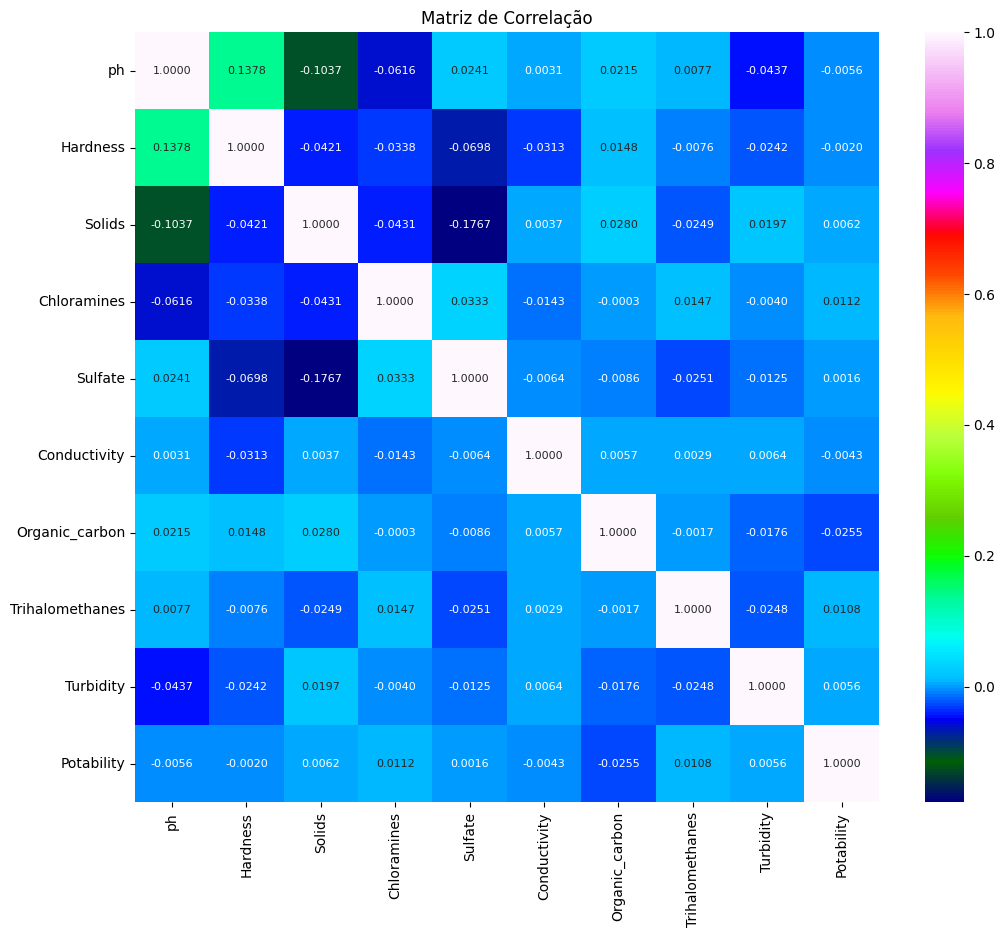

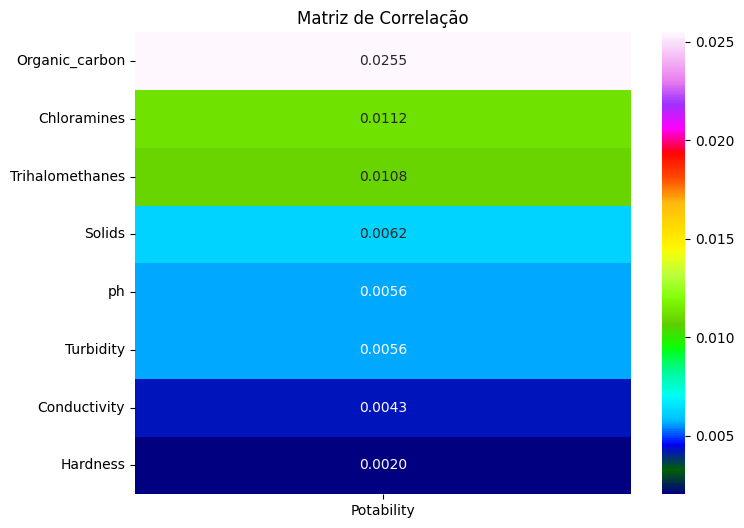

As variáveis que mais influenciam a variável alvo são:

                Potability
Organic_carbon    0.025484
Chloramines       0.011237


As variáveis que menos influenciam a variável alvo são:

              Potability
Hardness        0.002028
Conductivity    0.004289




In [27]:
correlation_matrix = dff.select_dtypes(include=['number']).corr()

correlation_matrix_filter = correlation_matrix[correlation_matrix['Potability']==1]

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 8})
plt.title('Matriz de Correlação')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(abs(correlation_matrix_filter.T).sort_values(by='Potability',ascending=False).iloc[range(1,9)], annot=True, cmap='gist_ncar', fmt=".4f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

print('As variáveis que mais influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='Potability', ascending=False).iloc[[1,2]]}\n\n')

print('As variáveis que menos influenciam a variável alvo são:\n')
print(f'{abs(correlation_matrix_filter.T).sort_values(by='Potability', ascending=True).iloc[[1,2]]}\n\n')

de maneira geral, todas estão correlacionadas, mesmo que os valores sejam baixos, são igualmente baixas

 Então agora podemos escolher qual o modelo será usado para treinar a predição de potabilidade.

### treinando o modelo

In [64]:
xo = dff.drop('Potability', axis = 1)
yo = dff['Potability']

scaler = StandardScaler()
xo = scaler.fit_transform(xo)

x_train, x_test, y_train, y_test = train_test_split(xo, yo, test_size=0.4, random_state=42)

xgboost

In [65]:
xgboost = xgb.XGBClassifier(random_state=42)
# crossvalidation = KFold(n_splits=folds, shuffle=True, random_

param_grid_xgboost = {
    'max_depth': [5, 10, 15],              
    'n_estimators': [50, 200, 300, 500],
    'min_child_weight': [1, 3, 5, 10, 15,20]
}

xgboost_randomized = RandomizedSearchCV(
    estimator= xgboost,
    param_distributions= param_grid_xgboost,
    n_iter=50,  
    random_state=42,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall', 
    n_jobs=-1  )



In [66]:
xgboost_randomized.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'max_depth': [5, 10, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [50, 200, ...]}"
,n_iter,50
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [67]:
best_xgboost = xgboost_randomized.best_estimator_
print("Melhores parâmetros:", xgboost_randomized.best_params_)
print("Melhor score (CV):", xgboost_randomized.best_score_)

Melhores parâmetros: {'n_estimators': 500, 'min_child_weight': 20, 'max_depth': 10}
Melhor score (CV): 0.4230392156862745


In [68]:
y_pred_xgboost = best_xgboost.predict(x_test)

In [69]:
# métricas de avaliação
acc_xgboost = accuracy_score(y_test, y_pred_xgboost)
rec_xgboost = recall_score(y_test, y_pred_xgboost, zero_division=0)
print(f"Acurácia: {acc_xgboost:.4f}")
print(f"Recall: {rec_xgboost:.4f}")
prec_xgboost = precision_score(y_test, y_pred_xgboost, zero_division=0)
f1_xgboost = f1_score(y_test, y_pred_xgboost, zero_division=0)
print(f"Precisão: {prec_xgboost:.4f}")
print(f"F1 score: {f1_xgboost:.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgboost, zero_division=0))

Acurácia: 0.5979
Recall: 0.3706
Precisão: 0.4557
F1 score: 0.4088
Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.66      0.73      0.70       670
         1.0       0.46      0.37      0.41       402

    accuracy                           0.60      1072
   macro avg       0.56      0.55      0.55      1072
weighted avg       0.58      0.60      0.59      1072



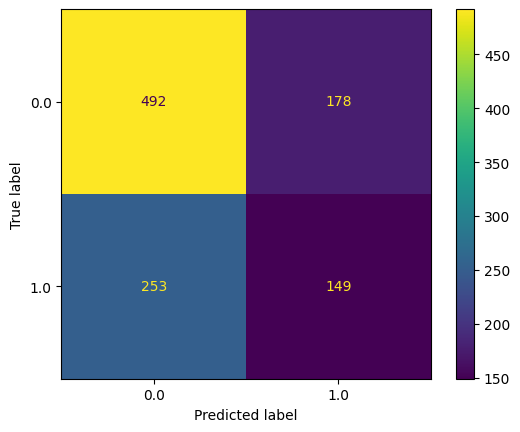

In [70]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgboost)